# Option analytics: letting the option surface choose the exposures

[`11a_pca`](11a_pca.ipynb) decomposed the panel of realized returns and used nothing else. It is
the control, and this notebook is the first thing measured against it.

**Instrumented PCA keeps the factor structure and conditions the exposures on the features.**
Where PCA gives each stock a loading estimated from its own return history, IPCA requires a
stock's exposure to be a linear function of *its own option-surface features on that date* -
implied volatility, the skew between puts and calls, the slope of the term structure, the gap
between implied and realized variance - and fits that map together with the factor returns. The
map is one set of coefficients shared by every stock and every date, so it is estimated on the
whole panel rather than on one cross-section at a time.

Two things follow from that, and they are the reason to read this notebook against
[`11a_pca`](11a_pca.ipynb) rather than on its own.

- **The features finally reach the factor structure.** In PCA they reached nothing. The distance
  between the two notebooks is what conditioning on the surface buys, measured rather than
  assumed, with the folds, the factor count and the scoring identical on both sides - though not
  the sample, for the reason the next point gives, which is why section 5 reads that distance as
  a bound rather than an estimate.
- **The panel no longer has to stay balanced.** PCA needs a stock to be the same stock with a
  usable return history across the training window. IPCA needs only that a stock have features on
  a date, because the exposure is computed from them rather than estimated from its past. On a
  universe that changes membership, that is the difference between dropping a name and pricing it.

**A model with no epochs still has a checkpoint.** `config/ipca/ipca.yaml` declares
`checkpoint_interval: 0`, because IPCA is fitted by alternating least squares run to convergence
rather than trained for a number of epochs: a fold produces one fitted map and one set of
predictions. That is why the plan below shows a single checkpoint where
[`08_tabular_dl`](08_tabular_dl.ipynb) shows eight, and it is a property of the estimator rather
than a reduced setting.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what conditioning an exposure on a characteristic changes, against estimating it from a
  return history.
- Explain why IPCA tolerates an unbalanced panel where PCA does not.
- Say what alternating least squares converging means here, and what the shared runner does when
  it does not.
- Read a population published for every declared label rather than for the traded one.

**Book reference**: Chapter 14, Section 14.5 (bridging economics and statistics with advanced
models). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run log this
notebook writes into.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds,
[`11_latent_factors`](11_latent_factors.ipynb) introduces the family, and
[`11a_pca`](11a_pca.ipynb) is the unconditioned baseline this one is read against.

**What it writes**: one training run per label and one complete validation prediction set per
label, in `run_log/registry.db` and under `run_log/training/` and `run_log/predictions/`, grouped
under a population named for this model. The family splits across five notebooks, so each
publishes its own population rather than one shared one.
[`13_model_analysis`](13_model_analysis.ipynb) compares them against the other families and
[`14_backtest`](14_backtest.ipynb) selects on validation backtest Sharpe. **Selection happens
there, not here.**

In [1]:
"""Fit the declared option-analytics IPCA population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    plan_models,
    planned_model_plan,
    primary_label,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""

MODEL_NAME = "ipca"

In [3]:
study = open_study(
    "sp500_equity_option_analytics",
    execution_tier=EXECUTION_TIER,
    workspace=WORKSPACE or None,
    entry_point="11b_ipca",
)

## 1. Which labels, and what the configuration says

Every label whose training menu declares `latent_factors:` is fitted, and the cell below reads
which those are rather than this sentence asserting a count that would go stale the moment a
sixth label declared the family. What the names mean is the part prose has to supply:
`fwd_ret_5d` is the stock's total return over the five trading days after the decision date,
`fwd_ret_10d` the same over ten, and `fwd_ret_risk_adj_5d` the five-day return divided by a
measure of its own dispersion. A `fwd_dir_*` classification label declaring only linear and
gradient boosting is absent here rather than dropped.

In [4]:
declared_labels(study, "latent_factors")

('fwd_ret_10d', 'fwd_ret_5d', 'fwd_ret_risk_adj_5d')

`case_studies/config/ipca/ipca.yaml` declares `n_factors`, how many common factors to extract,
and `checkpoint_interval: 0` for the reason given above. `config/setup.yaml` adds three more
under `modeling.latent_factors.model_kwargs.ipca`: `max_iter`, the alternating least squares
iteration budget, and `factor_ridge` and `gamma_ridge`, the penalties on its two least-squares
steps.

The order those are read in matters, because the same value can be declared twice.
`config/setup.yaml` wins where it declares a key, the preset supplies the rest, and a built-in
default is reached only when neither does. Here setup declares the iteration and ridge settings
and the preset declares `n_factors`, so nothing is contested. A reduced run may override either
through `PREVIEW_REDUCTIONS`, where the reduction becomes part of the preview identity rather
than a silent change - which matters for this model in particular, and section 3 says why.

In [5]:
configs = load_model_configs(
    study,
    "latent_factors",
    labels=LABELS or None,
    config_names=[MODEL_NAME],
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""latent_factors""","""fwd_ret_10d""","""ipca""","""""","""n_factors=5"""
"""latent_factors""","""fwd_ret_5d""","""ipca""","""""","""n_factors=5"""
"""latent_factors""","""fwd_ret_risk_adj_5d""","""ipca""","""""","""n_factors=5"""


`LABELS` narrows what is fitted, and a narrowed run declares a different set of members than the
canonical population does. A population is immutable once written, so such a run must publish
under its own name: on a fresh workspace it would otherwise register an incomplete snapshot under
the canonical one, and where the full population already exists the registry refuses it.

The comparison is against this model's own declared rows rather than the whole `latent_factors`
catalog. The family is split across five notebooks and each publishes one model, so the complete
catalog is five times what this one publishes, and comparing against it would report every
canonical run as narrowed.

In [6]:
declared = load_model_configs(study, "latent_factors", config_names=[MODEL_NAME])
if set(configs.get_column("label")) != set(declared.get_column("label")) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the {declared.height} declared labels, so it cannot "
        "publish the canonical population; pass POPULATION_NAME to give it its own"
    )

### Where this one runs, and why it is not the family's device

`config/setup.yaml` declares the latent-factor family on CUDA, which is right for the three
neural members. IPCA is not one of them: `run_ipca_fold` is alternating least squares over the
panel, numpy and scipy, and takes no device at all. The device nonetheless sits inside the hashed computation rather than
beside it as provenance, so leaving the family's value in place would record a computation that
did not happen and would make this population's identity depend on whether the machine had a GPU.
It is declared here instead, and a run on another device has to publish under its own name.

In [7]:
PUBLISHED_DEVICE = "cpu"
overrides = {"device": PUBLISHED_DEVICE}
print(f"training device: {PUBLISHED_DEVICE}")

training device: cpu


## 2. Binding the declarations to the data

A menu entry names an estimator and a factor count. It does not say which feature columns exist
today, where the walk-forward folds fall, or which symbol-date pairs have both a return and a
label. **Planning** works all of that out - and every training and prediction identity with it -
without fitting anything. Four things to check:

- **`feature_count` and `eligible_rows` agree across the rows.** A row that differs is a label
  measured on a different sample from its neighbours. They differ *between* labels, because a
  ten-day forward window runs out earlier than a five-day one.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  [`05_evaluation`](05_evaluation.ipynb) established.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out 2021 tail visible.
- **`checkpoints` is 1**, for the reason the configuration gives above.

`feature_count` means something here that it did not in [`11a_pca`](11a_pca.ipynb). There it was
a property of the request that the fit ignored, because a decomposition of the return panel uses
no feature columns. Here every one of those columns is an instrument: the map from features to
exposures carries a coefficient per column per factor, so `feature_count` times `n_factors` is
the size of what is being estimated, and it is the number to read against `eligible_rows` when
asking whether the panel can identify it.

In [8]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides=overrides,
    preview_reductions=PREVIEW_REDUCTIONS,
)
plan = plan_models(study, requests=requests)

planned_model_plan(plan).select(
    "label",
    "config_name",
    "task",
    "feature_count",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,task,feature_count,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,str,i64,i64,i64,i64,str,str
"""fwd_ret_10d""","""ipca""","""regression""",48,192139,2,1,"""2019-01-07 00:00:00""","""2020-12-16 00:00:00"""
"""fwd_ret_5d""","""ipca""","""regression""",48,194813,2,1,"""2019-01-07 00:00:00""","""2020-12-23 00:00:00"""
"""fwd_ret_risk_adj_5d""","""ipca""","""regression""",48,194748,2,1,"""2019-01-07 00:00:00""","""2020-12-23 00:00:00"""


The plan is also where a short population is visible. A run that fitted fewer labels than the
menu declares would still print an IC table and still register its rows; what it would not do is
announce the gap.

In [9]:
planned_pairs = {(member.label, member.config_name) for member in plan.members}
requested_pairs = set(zip(configs["label"], configs["config_name"], strict=True))
if planned_pairs != requested_pairs:
    raise RuntimeError(
        "the plan does not match the loaded IPCA menu; "
        f"missing {sorted(requested_pairs - planned_pairs)}, "
        f"unexpected {sorted(planned_pairs - requested_pairs)}"
    )
print(f"{len(requested_pairs)} label-configuration pairs")
print(f"{len(plan.expected_training_hashes)} training identities")
print(f"{len(plan.expected_prediction_hashes)} validation prediction sets")

3 label-configuration pairs
3 training identities
3 validation prediction sets


## 3. Fitting the population

`run_model_population` runs every planned request. For one request it walks the folds, and on
each one:

1. takes the stock-dates inside that fold's training window, with their features and returns,
2. alternates between two least-squares problems until they stop moving: given the current map
   from features to exposures, solve for the factor returns on each date; given those factor
   returns, solve for the map. Both steps are ridge-penalised at the strengths
   `config/setup.yaml` declares,
3. applies the fitted map to the validation dates' features to get each stock's exposure there,
   and multiplies by the training window's factor returns to get a predicted return.

Step 3 is what makes this a forecast rather than a decomposition: the map and the factor returns
come from the training window only, and the validation dates contribute nothing to either.

**Alternating least squares can fail to converge, and the shared runner refuses the result when
it does.** `case_studies/utils/latent_factors/cv.py` collects each fold's convergence flag and
raises before anything is registered, rather than publishing predictions from an incomplete fit.
That is worth knowing as a reader because the failure is a property of the data rather than of
the code: the map has `feature_count` times `n_factors` coefficients to identify, and a
cross-section with fewer names than that on a date cannot identify them at any iteration budget.
It is why the CI fixture for this notebook declares a reduced `n_factors` - twenty-odd symbols
per date do not identify five factors - and why that reduction is declared in
`PREVIEW_REDUCTIONS`, where it changes the preview identity instead of quietly relaxing a guard.

**This notebook passes the plan rather than resolved requests, and on this family that changes
what the plan table can show rather than how the fitting is ordered.** The linear, boosted and
TabM adapters each provide a batch runner that prepares one fold set for several configurations;
the latent-factor adapter provides none, so every request is fitted on its own whichever path is
taken. There would be nothing to share in any case: this notebook publishes one model against
three labels, and each label is a different set of rows. What passing the plan costs is
`eligible_entities`, which needs the eligibility keys themselves; `eligible_rows` above moves
whenever the universe does, so the check that column existed for is still made.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [10]:
def catalog_labels(execution) -> int:
    """Number of distinct labels the execution published, read from its catalog rows."""
    return execution.catalog_rows.get_column("label").n_unique()


population_name = POPULATION_NAME or f"sp500_equity_option_analytics-{MODEL_NAME}-validation-v1"
execution, population = run_model_population(
    study, plan, population_name=population_name, supersedes=SUPERSEDES_POPULATION or None
)

# No per-fold counts: this family's runner reports none, and two zeros would read as a failed fit.
print(f"{len(execution.runs)} training runs across {catalog_labels(execution)} labels")
print(f"population {population.name}: {len(population.members)} prediction sets")

3 training runs across 3 labels
population sp500_equity_option_analytics-ipca-validation-v1: 3 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the registry
already holds the matching rows, and the runner returns the stored result rather than fitting
again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("sp500_equity_option_analytics", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "latent_factors", labels=["fwd_ret_5d"], config_names=["pca"]
)
requests = model_requests(study, configs, overrides={"device": "cpu"})
plan = plan_models(study, requests=requests)
execution, population = run_model_population(study, plan, population_name="my-pca-v1")
```

To change the number of factors for your own run, edit `case_studies/config/pca/pca.yaml`, or
declare `n_factors` under `modeling.latent_factors.model_kwargs.pca` in `config/setup.yaml` to
override the preset for this case study alone. Note which of those you want: the preset is shared
by every case study that declares `pca`, so editing it moves the training identity of all of
them. Either way the result registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per label. The **information coefficient** is the rank correlation, on one validation
date, between the stocks ordered by the model's prediction and the stocks ordered by the return
they went on to earn.

`ic_mean` aggregates that **over folds, not over days**: each fold's own mean IC is computed and
those are averaged with equal weight (`latent_factors/cv.py`, and
`registry/metrics.py` states the convention). With folds of unequal length the fold mean and the
pooled daily mean are different numbers, and this column is the first.

`ic_n_days` is how many validation dates produced a defined correlation, and it decides which rows
are comparable with each other. `auc_scored_against` says what the AUC column was scored against:
a regression row has no classes of its own and is scored as a ranking signal against a declared
direction sibling, so `fwd_ret_5d` is scored against `fwd_dir_5d` and `fwd_ret_10d` against
`fwd_dir_10d`. `fwd_ret_risk_adj_5d` declares no sibling and carries no AUC; null there means not
computed, not zero.

The published catalog is checked against the population planned before fitting rather than against
its own row count, because a run that lost a member would otherwise report a shorter table and
nothing else.

In [11]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "task",
    "complete",
    "checkpoint_kind",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_t",
    "ic_n_days",
    "auc_mean_daily",
    pl.col("direction_label").alias("auc_scored_against"),
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("label")

if set(catalog.get_column("prediction_hash")) != set(plan.expected_prediction_hashes):
    raise RuntimeError("the published catalog differs from the population planned before fitting")
if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("a partial IPCA prediction set cannot pass to backtesting")
if catalog.select("label", "config_name", "checkpoint_value").n_unique() != catalog.height:
    raise RuntimeError("each label and checkpoint must identify one prediction set")

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders by whichever
# label it did fit rather than by one that is not there.
ordered_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
print(f"{catalog.height} candidate models across {len(ordered_labels)} labels")
catalog.select(
    "label",
    "task",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_t",
    "ic_n_days",
    "auc_mean_daily",
    "auc_scored_against",
)

3 candidate models across 3 labels


label,task,checkpoint_value,ic_mean,ic_std,ic_t,ic_n_days,auc_mean_daily,auc_scored_against
str,str,i64,f64,f64,f64,f64,f64,str
"""fwd_ret_10d""","""regression""",0,-0.008197,0.019054,-0.608413,492.0,0.511589,"""fwd_dir_10d"""
"""fwd_ret_5d""","""regression""",0,0.001611,0.008735,0.260787,497.0,0.511944,"""fwd_dir_5d"""
"""fwd_ret_risk_adj_5d""","""regression""",0,0.014003,0.006981,2.836809,497.0,null,null


### One map, three targets

The features, the folds, the factor count and the ridge strengths are identical across these
rows. What changes is which forward return the exposures were fitted against - and unlike
[`11a_pca`](11a_pca.ipynb), where the decomposition never saw the target at all, here the target
enters the fit. So a gap between these rows says the map itself came out different, not just that
the same forecast was scored three ways.

`ic_t` is the t-statistic across those fold means, not a Newey-West statistic on the daily
series - the registry keeps the HAC-corrected version separately as `ic_t_hac`, and that is the
inferential one. Either way it is a diagnostic and not a selection rule: the series is short,
overlapping multi-day returns make successive days dependent, and the folds have been read many
times over by the time a case study reaches this notebook.

In [12]:
by_label = catalog.select(
    "label",
    "task",
    ic_mean=pl.col("ic_mean"),
    ic_t=pl.col("ic_t"),
    scored_dates=pl.col("ic_n_days"),
    # `ic_n_days` counts the days behind `ic_mean_daily`, the pooled daily statistic - not the
    # folds behind `ic_mean`, which is what the rows are ordered by. So this column is a
    # comparability guarantee about one statistic attached to a ranking on another. It is kept
    # because unequal day counts are still the thing that makes two rows incomparable, and
    # flagged because the two are not the same measurement: `registry/metrics.py:203` averages
    # folds for `ic_mean`, and `:234-250` computes the daily family together. Reading the
    # ordering on `ic_mean_daily` would need `PredictionCatalog` to carry it.
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max(),
).sort("ic_mean", descending=True)
by_label

label,task,ic_mean,ic_t,scored_dates,full_coverage
str,str,f64,f64,f64,bool
"""fwd_ret_risk_adj_5d""","""regression""",0.014003,2.836809,497.0,true
"""fwd_ret_5d""","""regression""",0.001611,0.260787,497.0,true
"""fwd_ret_10d""","""regression""",-0.008197,-0.608413,492.0,false


### The same map against each target

One bar per label, on one axis, with the primary target first. The bars are the quantity the
downstream comparison uses; the axis is shared so the distance between them is readable rather
than each panel filling itself.

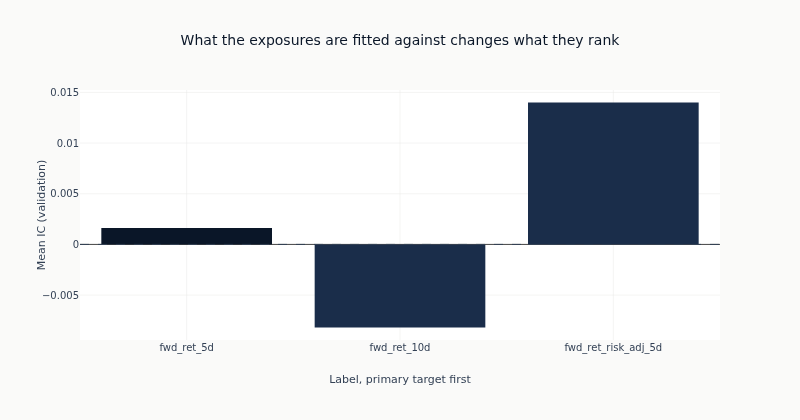

In [13]:
panel = catalog.with_columns(
    rank=pl.col("label").replace_strict(
        {label: index for index, label in enumerate(ordered_labels)}, return_dtype=pl.Int32
    )
).sort("rank")
fig = go.Figure(
    go.Bar(
        x=panel.get_column("label").to_list(),
        y=panel.get_column("ic_mean").to_list(),
        marker_color=[
            COLORS["blue"] if label == primary else COLORS["slate"]
            for label in panel.get_column("label")
        ],
        showlegend=False,
    )
)
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_yaxes(title_text="Mean IC (validation)")
fig.update_xaxes(title_text="Label, primary target first")
fig.update_layout(
    title="What the exposures are fitted against changes what they rank",
    height=420,
    width=800,
    margin=dict(t=90),
)
# Which side of zero each bar sits on is a fact about the frame, so the alt text reads it rather
# than asserting a shape the next run may not reproduce.
sides = "; ".join(
    f"{row['label']} {'above' if row['ic_mean'] > 0 else 'below'} zero"
    for row in panel.select("label", "ic_mean").iter_rows(named=True)
)
show_plotly_with_alt(
    fig,
    "Bar chart of mean validation information coefficient, one bar per label on one axis, with the "
    "primary target in dark navy first and the two variants in slate, and a dashed zero line. "
    f"Counted from the frame: {sides}.",
)

## 5. What to notice

**The estimator is the same and only the target moves.** These rows share the features, the
folds, the dates scored, the factor count and the ridge strengths. `fwd_ret_10d` is the same
construction over twice the horizon, and `fwd_ret_risk_adj_5d` is `fwd_ret_5d` divided by a
measure of its own dispersion - so a gap between those two rows is a statement about scaling by
width and nothing else.

**This notebook and [`11a_pca`](11a_pca.ipynb) differ in two things, not one, and the second one
limits what the comparison can say.** Same folds, same factor count, same scoring, same three
labels. PCA estimates each stock's loading from its own return history and never sees an
option-surface column; IPCA requires the loading to be a linear function of exactly those
columns. That is the difference the comparison is for.

The second difference is the sample. The section above is explicit that IPCA does not need a
balanced panel and PCA does, and the consequence is that the two populations are not scored on
the same rows: IPCA covers about a tenth more of the panel on every label - 192,139 against
175,360 on `fwd_ret_10d`, 194,813 against 177,682 on `fwd_ret_5d`, 194,748 against 177,769 on
`fwd_ret_risk_adj_5d`. The extra rows are the names PCA had to drop for want of a complete return
history, which are systematically the shorter-lived and less liquid ones.

So the gap between the two ICs is what conditioning buys **plus** whatever those rows contribute,
and this notebook cannot separate them. Read it as a bound rather than an estimate, and read it
in both directions, because a constraint that is wrong costs more than no constraint at all.
Making it an estimate would mean scoring IPCA on PCA's balanced subset, which is a different
notebook and would throw away the tolerance that is IPCA's main practical advantage.

**A model with no epochs still has a checkpoint, and the checkpoint is not a formality.** The
registry keys a prediction set on `(training identity, checkpoint)`, so a family whose members
publish one, five and ten checkpoints each needs one convention rather than three. IPCA publishes
at zero because alternating least squares runs to convergence: there is no intermediate state a
reader could have stopped at, and inventing one would offer a choice the estimator does not
have.
[`11c_conditional_autoencoder`](11c_conditional_autoencoder.ipynb) is the contrast, where the
stopping point is real and is published.

**What IPCA buys over predicting the return directly is a constraint, not more capacity.** The
supervised models had one weight per feature and one cross-section at a time to find it in. IPCA
has one map from the features to `n_factors` exposures, shared by every stock and every date, and
the factor returns are then whatever best explains each date given those exposures. That is far
fewer free numbers against far more data, and it is the entire argument for the family. It is
also the limitation: if a feature's relationship to its exposure is not linear, the constraint is
wrong rather than merely tight, which is what
[`11c_conditional_autoencoder`](11c_conditional_autoencoder.ipynb) relaxes.

**None of this selects anything.** IC measures whether predictions rank stocks correctly, not
whether a strategy trading them makes money after costs and turnover, and every label's
prediction set stays in the published population for that reason. Selection is on validation
backtest Sharpe in [`14_backtest`](14_backtest.ipynb).

**Known limitations.** Two folds, one of them validating on 2020, a year in which the
cross-section co-moved unlike any other in the sample - which bears on a factor model more
directly than on a supervised one, because co-movement is the thing being estimated. The number
of factors and both ridge strengths are declared rather than chosen, and nothing here tests
whether other values would order the cross-section better; that would be a search, and a search
over validation IC is what this notebook is arranged to avoid. The exposures are assumed linear
in the features and constant within a date. The IC carries no adjustment for the serial
dependence overlapping multi-day returns create, so it is a ranking diagnostic rather than a
test.

**Next**: [`11c_conditional_autoencoder`](11c_conditional_autoencoder.ipynb) keeps this exact
structure - features to exposures, exposures times factor returns - and replaces the linear map
with a neural network, so the difference between those two notebooks is the shape of one function
and nothing else.